# Pipeline 8: Intervention Mix Effectiveness

## Which intervention combinations are most effective during counseling sessions?

**Notebook:** `intervention-mix-effectiveness.ipynb`  
**Domain:** Case Management and Counseling  
**Purpose:** study how the mix of interventions used in a session relates to emotional improvement and concern flags.

---

## 1. Problem framing

### Business question
When a counselor uses different combinations of interventions, do some mixes correlate with better emotional outcomes or lower escalation risk?

### Predictive and explanatory goals
- **Explanatory model:** estimate how session duration, intervention mix, resident context, and prior session history relate to emotional change.
- **Predictive model:** predict whether a session will be marked `concerns_flagged` using only information available before or during the session.

### Who uses this
- **Supervisors** to spot sessions that may need immediate review
- **Social workers** to understand which intervention bundles tend to work better
- **Leadership** to standardize effective counseling practices

---

## 2. Data and feature engineering

### Primary data source
- `process_recordings`
- joined with resident context from `residents`

### Core features
- Session duration
- Session type: individual vs group
- Starting and ending emotional state
- Emotional delta / shift
- Number of interventions applied
- Indicator features for the most common intervention tokens
- Resident history: prior session count, prior concern rate, prior mean duration, and the most recent prior emotional state
- Context variables such as case category, referral source, current risk level, and safehouse assignment

### Leakage control
History features are built only from sessions that happened earlier for the same resident, so the model does not peek into the future.

---

## 3. Modeling approach

### Explanatory track
A linear regression model estimates how the intervention mix is associated with emotional improvement.

### Predictive track
A random forest classifier predicts whether a session will be flagged for concern. A dummy baseline is included to show whether the model adds real signal.

### Validation strategy
- Group-aware holdout by resident
- 5-fold group cross-validation
- Permutation importance for the strongest predictive drivers

---

## 4. What the dashboard can show

### Useful insights
- Which intervention tokens appear most often in high-improvement sessions
- Whether longer sessions correlate with better emotional change
- How strongly prior resident history affects the likelihood of concern
- Which resident profiles need more supervision

### Decision output
This notebook supports a counselor triage view: surface sessions with high predicted concern, then let supervisors review the most important historical and session-level signals.

---

## 5. Caveats
This is observational analysis. A high coefficient for an intervention does not prove the intervention caused the improvement, because counselors may choose interventions based on case severity.

### Cursor / kernel

**Option A — use your existing intern venv**

```bash
~/Desktop/intern/.venv/bin/python -m pip install -U ipykernel matplotlib
~/Desktop/intern/.venv/bin/python -m ipykernel install --user --name=intern-venv --display-name "Python (intern)" --force
```

Then **Cmd+Shift+P** → **Python: Select Interpreter** → `~/Desktop/intern/.venv/bin/python`, and pick the same kernel in the notebook (top right).

**Option B — repo venv (recommended for this project)**

From `z_intex2/ml-pipelines` run: `scripts/bootstrap_notebook_venv.sh` — then choose interpreter `ml-pipelines/.venv/bin/python`.

In [1]:
import sys
print("Using interpreter:\n ", sys.executable)
print("\nIf this is not your venv, use Cmd+Shift+P → Python: Select Interpreter, then re-pick the notebook kernel.")

Using interpreter:
  /Users/graywheeler/Desktop/intern/.venv/bin/python

If this is not your venv, use Cmd+Shift+P → Python: Select Interpreter, then re-pick the notebook kernel.


In [2]:

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import sys
from pathlib import Path
for candidate in [Path.cwd(), Path.cwd() / 'ml-pipelines', Path.cwd().parent, Path.cwd().parent / 'ml-pipelines']:
    if (candidate / 'data_loader.py').exists():
        sys.path.insert(0, str(candidate))
        break
from data_loader import load_table

p = load_table('process_recordings').sort_values('session_date').copy()
res = load_table('residents')[
    ['resident_id', 'safehouse_id', 'case_category', 'referral_source', 'current_risk_level']
]
p = p.merge(res, on='resident_id', how='left')

emotion_map = {'Distressed': 1, 'Withdrawn': 2, 'Sad': 2, 'Anxious': 2, 'Angry': 2, 'Calm': 4, 'Hopeful': 5, 'Happy': 5}
p.loc[:, 'emo_start'] = p['emotional_state_observed'].map(emotion_map).fillna(3)
p.loc[:, 'emo_end'] = p['emotional_state_end'].map(emotion_map).fillna(3)
p.loc[:, 'emo_delta'] = (p['emo_end'] - p['emo_start']).clip(-3, 3)
p.loc[:, 'intervention_count'] = p['interventions_applied'].fillna('').str.count(',') + 1
p.loc[p['interventions_applied'].fillna('') == '', 'intervention_count'] = 0
p.loc[:, 'high_concern'] = p['concerns_flagged'].astype(int)
p.loc[:, 'is_individual'] = (p['session_type'] == 'Individual').astype(int)
p.loc[:, 'is_group'] = (p['session_type'] == 'Group').astype(int)
p.loc[:, 'group_x_intervention_ct'] = p['is_group'] * p['intervention_count']

# Top intervention tokens (comma-separated labels)
tok_series = p['interventions_applied'].fillna('').str.split(',').apply(
    lambda xs: [t.strip() for t in xs if t.strip()]
)
all_toks = [t for row in tok_series for t in row]
top_toks = list(pd.Series(all_toks).value_counts().head(6).index)
for i, t in enumerate(top_toks):
    p.loc[:, f'tok_w{i}'] = p['interventions_applied'].fillna('').str.contains(t, regex=False).astype(int)


def enrich_history(sub: pd.DataFrame) -> pd.DataFrame:
    sub = sub.sort_values('session_date').copy()
    prior_n = []
    prior_concern = []
    prior_dur = []
    lag1_emo = []
    for _, row in sub.iterrows():
        t = row['session_date']
        past = sub[sub['session_date'] < t]
        prior_n.append(len(past))
        prior_concern.append(float(past['concerns_flagged'].astype(int).mean()) if len(past) else 0.0)
        prior_dur.append(float(past['session_duration_minutes'].mean()) if len(past) else float(row['session_duration_minutes']))
        lag1_emo.append(float(past['emo_start'].iloc[-1]) if len(past) else 3.0)
    sub.loc[:, 'prior_session_count'] = prior_n
    sub.loc[:, 'prior_mean_concern'] = prior_concern
    sub.loc[:, 'prior_mean_duration'] = prior_dur
    sub.loc[:, 'lag1_emo_start'] = lag1_emo
    return sub

parts = [enrich_history(g) for _, g in p.groupby('resident_id', sort=False)]
p = pd.concat(parts, ignore_index=True)

base_feats = [
    'session_duration_minutes', 'is_individual', 'is_group', 'emo_start', 'intervention_count',
    'group_x_intervention_ct', 'social_worker', 'safehouse_id', 'case_category', 'referral_source',
    'current_risk_level', 'prior_session_count', 'prior_mean_concern', 'prior_mean_duration', 'lag1_emo_start',
]
tok_cols = [c for c in p.columns if c.startswith('tok_w')]
features = base_feats + tok_cols
X = p[features].copy()
y_reg = p['emo_delta']
y_clf = p['high_concern']

# Explicit schema: IDs like social_worker (e.g. SW-04) may be pandas "category" dtype and must
# not go through median imputation.
num_cols = [
    'session_duration_minutes', 'is_individual', 'is_group', 'emo_start', 'intervention_count',
    'group_x_intervention_ct', 'safehouse_id', 'prior_session_count', 'prior_mean_concern',
    'prior_mean_duration', 'lag1_emo_start',
] + tok_cols
cat_cols = ['social_worker', 'case_category', 'referral_source', 'current_risk_level']
X[num_cols] = X[num_cols].apply(pd.to_numeric, errors='coerce')
for c in cat_cols:
    X[c] = X[c].astype('string').fillna('Unknown')

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_te = next(gss.split(X, y_clf, groups=p['resident_id']))
Xtr, Xte = X.iloc[idx_tr], X.iloc[idx_te]
ytr_reg, yte_reg = y_reg.iloc[idx_tr], y_reg.iloc[idx_te]
ytr_clf, yte_clf = y_clf.iloc[idx_tr], y_clf.iloc[idx_te]

prep = ColumnTransformer(
    [
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
        ('cat', Pipeline([('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ],
    n_jobs=1,
)

lin = Pipeline([('prep', prep), ('model', LinearRegression())])
lin.fit(Xtr, ytr_reg)
pred_reg = lin.predict(Xte)
print('Explanatory R2:', round(r2_score(yte_reg, pred_reg), 3))
print('Explanatory MAE:', round(mean_absolute_error(yte_reg, pred_reg), 3))

baseline = Pipeline([('prep', prep), ('model', DummyClassifier(strategy='prior'))])
rf = Pipeline([('prep', prep), ('model', RandomForestClassifier(
    n_estimators=280, random_state=42, min_samples_leaf=4, class_weight='balanced_subsample'))])
baseline.fit(Xtr, ytr_clf)
rf.fit(Xtr, ytr_clf)
base_proba = baseline.predict_proba(Xte)[:, 1]
rf_proba = rf.predict_proba(Xte)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)
print('Baseline AUC:', round(roc_auc_score(yte_clf, base_proba), 3))
print('RF AUC:', round(roc_auc_score(yte_clf, rf_proba), 3))
print('RF F1:', round(f1_score(yte_clf, rf_pred, zero_division=0), 3))

gkf = GroupKFold(n_splits=min(5, p['resident_id'].nunique()))
cv = cross_validate(
    rf, X, y_clf, cv=gkf, scoring=['roc_auc', 'f1'], groups=p['resident_id'].values, n_jobs=1,
)
print('CV AUC mean/std:', round(float(cv['test_roc_auc'].mean()), 3), round(float(cv['test_roc_auc'].std()), 3))

perm = permutation_importance(rf, Xte, yte_clf, n_repeats=8, random_state=42, scoring='roc_auc')
imp_full = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
imp = imp_full.head(12)
perm_importance_top = imp_full.head(10)
print('\nTop predictive drivers:')
print(imp.round(4).to_string())

coef_values = np.ravel(lin.named_steps['model'].coef_)
coef_names = lin.named_steps['prep'].get_feature_names_out()
usable = min(len(coef_values), len(coef_names))
coef = pd.Series(coef_values[:usable], index=coef_names[:usable]).sort_values(key=lambda s: s.abs(), ascending=False).head(12)
print('\nTop explanatory effects:')
print(coef.round(4).to_string())

print('\nDecision recommendations: route high predicted concern sessions to supervisors; prioritize bundles where history + session context show stable gains.')


Explanatory R2: 0.471
Explanatory MAE: 0.603
Baseline AUC: 0.5
RF AUC: 0.507
RF F1: 0.083
CV AUC mean/std: 0.518 0.023

Top predictive drivers:
current_risk_level         0.0078
prior_session_count        0.0052
prior_mean_concern         0.0049
emo_start                  0.0038
intervention_count         0.0014
group_x_intervention_ct    0.0012
tok_w2                    -0.0007
is_group                  -0.0013
lag1_emo_start            -0.0026
is_individual             -0.0033
tok_w3                    -0.0034
tok_w0                    -0.0037

Top explanatory effects:
num__emo_start                     -0.8799
cat__social_worker_SW-12           -0.1554
cat__social_worker_SW-18           -0.1297
cat__social_worker_SW-16            0.1258
cat__social_worker_SW-07            0.1237
cat__social_worker_SW-14            0.1046
cat__social_worker_SW-10           -0.1043
cat__social_worker_SW-19           -0.0979
cat__social_worker_SW-09            0.0974
cat__current_risk_level_Critical   

## Visual summaries

Run the **kernel check** cell, then the **modeling** cell above, then this one. Plots need `p`, `top_toks`, and `perm_importance_top`.

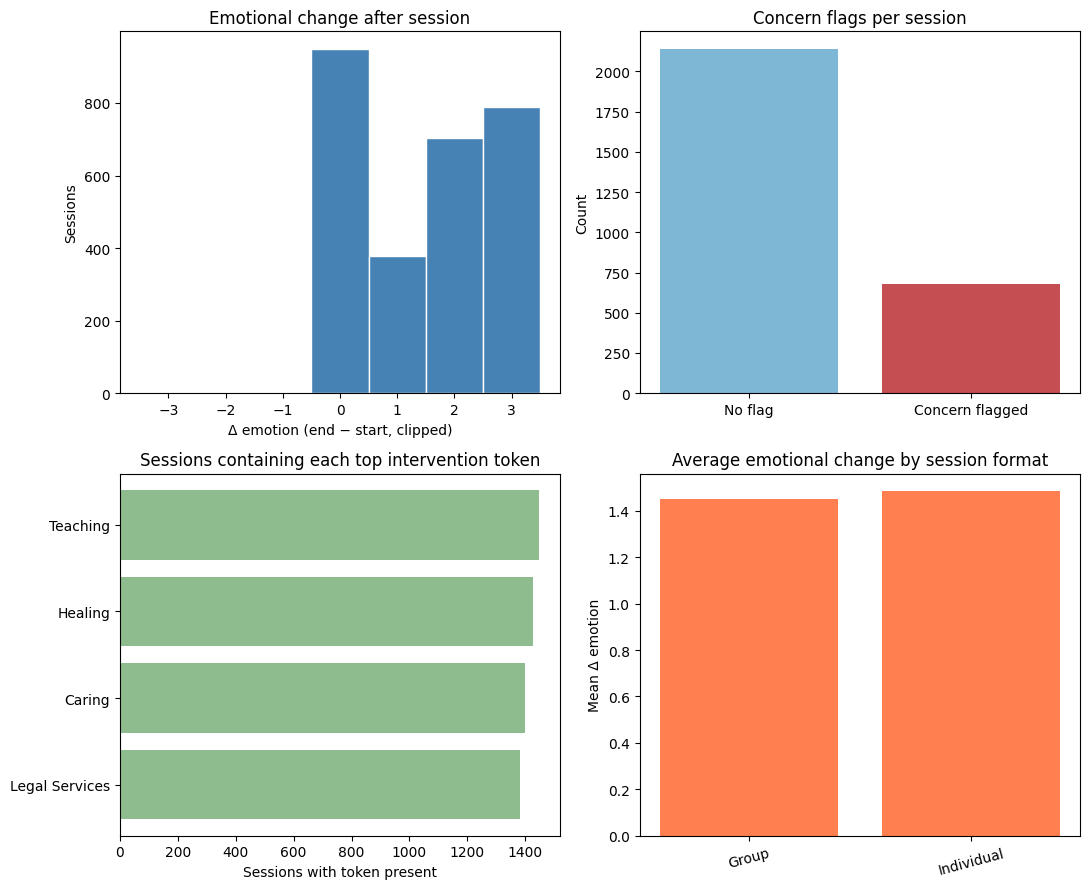

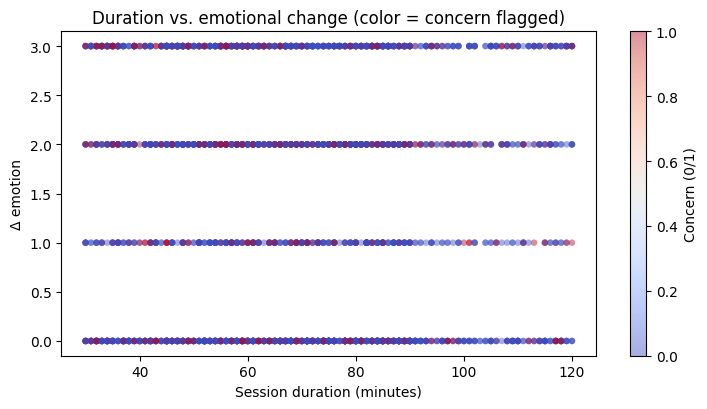

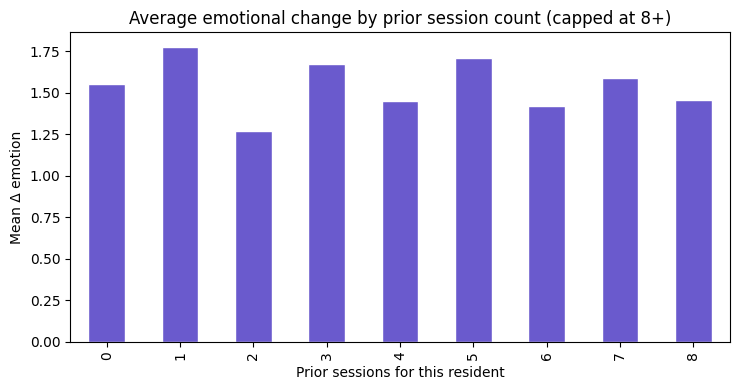

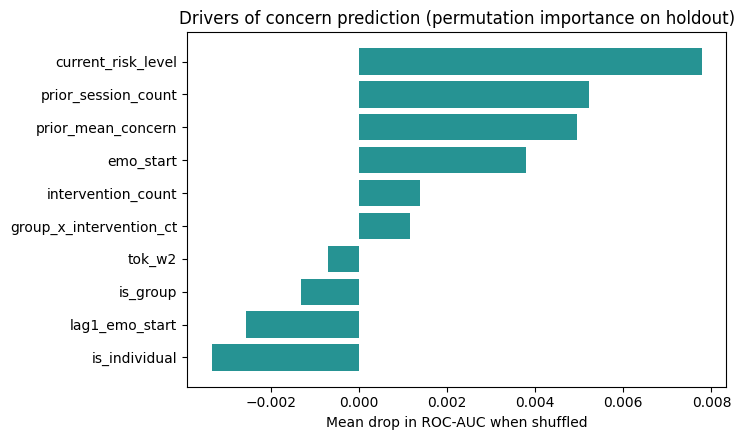

In [3]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except (NameError, AttributeError):
    pass

import matplotlib.pyplot as plt

_missing = [n for n in ('p', 'top_toks', 'perm_importance_top') if n not in globals()]
if _missing:
    raise RuntimeError('Run the modeling cell first; missing: ' + ', '.join(_missing))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

edges = np.arange(-3.5, 4.5, 1)
axes[0, 0].hist(p['emo_delta'].dropna().values, bins=edges, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Emotional change after session')
axes[0, 0].set_xlabel('Δ emotion (end − start, clipped)')
axes[0, 0].set_ylabel('Sessions')

conc = p['high_concern'].value_counts().reindex([0, 1]).fillna(0).astype(int)
axes[0, 1].bar(['No flag', 'Concern flagged'], conc.values, color=['#7eb6d6', '#c44e52'])
axes[0, 1].set_title('Concern flags per session')
axes[0, 1].set_ylabel('Count')

tok_counts = [int(p[f'tok_w{i}'].sum()) for i in range(len(top_toks))]
axes[1, 0].barh(top_toks[::-1], tok_counts[::-1], color='darkseagreen')
axes[1, 0].set_title('Sessions containing each top intervention token')
axes[1, 0].set_xlabel('Sessions with token present')

mean_by_type = p.groupby('session_type', dropna=False)['emo_delta'].mean().sort_values()
axes[1, 1].bar(mean_by_type.index.astype(str), mean_by_type.values, color='coral')
axes[1, 1].set_title('Average emotional change by session format')
axes[1, 1].set_ylabel('Mean Δ emotion')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(7.5, 4.2))
sc = ax.scatter(
    p['session_duration_minutes'],
    p['emo_delta'],
    c=p['high_concern'],
    cmap='coolwarm',
    alpha=0.45,
    s=22,
    edgecolors='none',
)
ax.set_xlabel('Session duration (minutes)')
ax.set_ylabel('Δ emotion')
ax.set_title('Duration vs. emotional change (color = concern flagged)')
plt.colorbar(sc, ax=ax, label='Concern (0/1)')
plt.tight_layout()
plt.show()

fig3, ax = plt.subplots(figsize=(7.5, 4))
p.groupby(p['prior_session_count'].clip(upper=8))['emo_delta'].mean().plot(
    kind='bar', ax=ax, color='slateblue', edgecolor='white'
)
ax.set_title('Average emotional change by prior session count (capped at 8+)')
ax.set_xlabel('Prior sessions for this resident')
ax.set_ylabel('Mean Δ emotion')
plt.tight_layout()
plt.show()

fig4, ax = plt.subplots(figsize=(7.5, 4.5))
pi = perm_importance_top.iloc[::-1]
ax.barh(pi.index.astype(str), pi.values, color='teal', alpha=0.85)
ax.set_title('Drivers of concern prediction (permutation importance on holdout)')
ax.set_xlabel('Mean drop in ROC-AUC when shuffled')
plt.tight_layout()
plt.show()

In [4]:
import sys
from pathlib import Path
for candidate in [Path.cwd(), Path.cwd() / 'ml-pipelines', Path.cwd().parent, Path.cwd().parent / 'ml-pipelines']:
    if (candidate / 'trend_eval_helpers.py').exists():
        sys.path.insert(0, str(candidate))
        break
from trend_eval_helpers import print_calibration_bins, print_threshold_scan, bootstrap_linear_coefs, fairness_binary, fairness_regression_mae

print("\n=== Evaluation artifacts ===")
if yte_clf.nunique() >= 2:
    proba = rf.predict_proba(Xte)[:, 1]
    print_calibration_bins(yte_clf.values, proba)
    print_threshold_scan(yte_clf.values, proba)
    fairness_binary(rf, Xte, yte_clf, p.loc[Xte.index], ['safehouse_id', 'case_category'], min_n=20)
bootstrap_linear_coefs(lin, Xtr, ytr_reg, n_boot=150, top_k=8)



=== Evaluation artifacts ===
  bin [0.20,0.30): n=48 mean_pred=0.273 rate_pos=0.188
  bin [0.30,0.40): n=280 mean_pred=0.351 rate_pos=0.239
  bin [0.40,0.50): n=189 mean_pred=0.437 rate_pos=0.212
  bin [0.50,0.60): n=23 mean_pred=0.516 rate_pos=0.261
  thr  prec   rec    F1
  0.1  0.226  1.000  0.369
  0.2  0.226  1.000  0.369
  0.3  0.230  0.926  0.368
  0.4  0.217  0.377  0.275
  0.5  0.261  0.049  0.083
  0.6  0.000  0.000  0.000
  0.7  0.000  0.000  0.000
  0.8  0.000  0.000  0.000
  0.9  0.000  0.000  0.000

--- Fairness-style slices (AUC), min_n=20 ---
  safehouse_id=2: n=71 AUC=0.536
  safehouse_id=7: n=160 AUC=0.525
  safehouse_id=4: n=148 AUC=0.454
  safehouse_id=5: n=118 AUC=0.595
  safehouse_id=8: n=43 AUC=0.64
  case_category=Surrendered: n=46 AUC=0.545
  case_category=Abandoned: n=154 AUC=0.529
  case_category=Foundling: n=234 AUC=0.538
  case_category=Neglected: n=106 AUC=0.407
  feature  median  p2.5  p97.5
  num__emo_start                                    -0.8766  -0